<a href="https://colab.research.google.com/github/shreyashbhat1111/Medicine-reminder/blob/main/ML_Practical1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
#create the dataset
data = {
    "Study_Hours":[1,2,3,4,5,6,7,8,9,10],
    "Attendence":[60,85,70,95,65,80,90,75,88,72],
    "Marks":[32,42,47,58,61,67,76,79,88,91]
}
df=pd.DataFrame(data)
print(df)

   Study_Hours  Attendence  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


In [123]:
print('First Five Rows:')
df.shape

First Five Rows:


(10, 3)

In [124]:
print('shape of Dataset:')
df.shape

shape of Dataset:


(10, 3)

In [125]:
print('Information:')
df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendence   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [126]:
print('Statistical Analysis:\n',df.describe())

Statistical Analysis:
        Study_Hours  Attendence      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [127]:
print('check for null values:')
df.isnull().sum()

check for null values:


,0
Study_Hours,0
Attendence,0
Marks,0


In [128]:
#Duplicate Values
df.duplicated().sum()

np.int64(0)

In [129]:
df.drop_duplicates()

,Study_Hours,Attendence,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


Text(0.5, 1.0, 'correlation Heatmap')

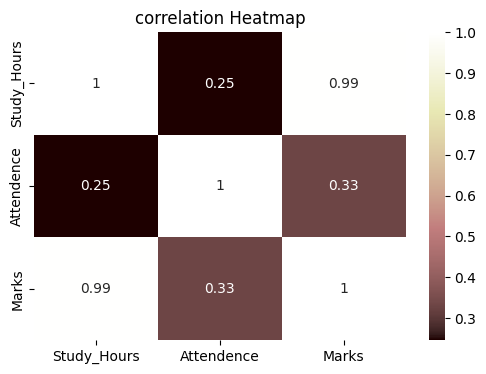

In [130]:
import seaborn as sns
df_corr=df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(df_corr,annot=True,cmap='pink')
plt.title('correlation Heatmap')

In [131]:
x=df[['Study_Hours']]
y=df['Marks']

In [132]:
from sklearn.model_selection import train_test_split
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [133]:
x_test

,Study_Hours
8,9
1,2
5,6


In [134]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [135]:
y_pred=model.predict(x_test)
y_pred

array([86.55445545, 41.22772277, 67.12871287])

In [136]:
print('Intercept:',model.intercept_)
print('Slope:',model.coef_[0])

Intercept: 28.277227722772274
Slope: 6.475247524752477


In [137]:
#Evaluation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [138]:
print('RSME:', round(rmse, 3))
print('R2 Score:', round(r2, 2))

RSME: 0.949
R2 Score: 1.0


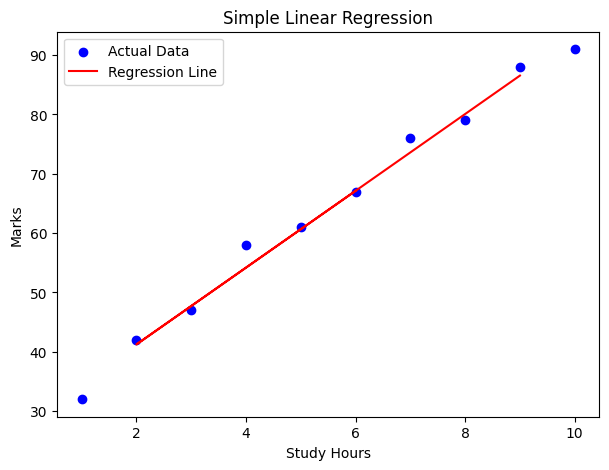

In [139]:
# Regression Line

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred,
         color='red',
         label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()

plt.show()

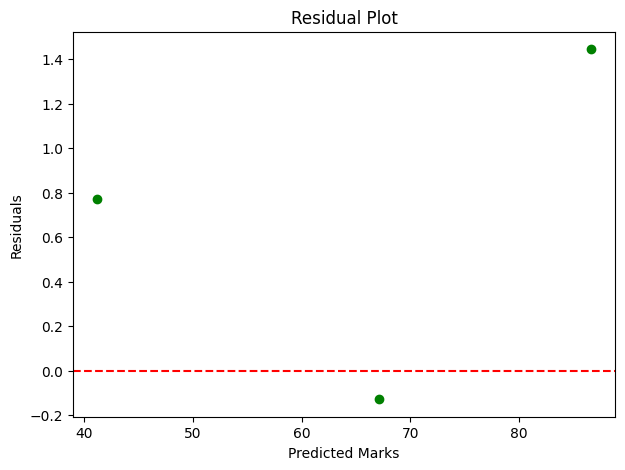

In [140]:
residuals = y_test - y_pred # Calculate Residual

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0,
            color='red',
            linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [141]:
# Independent Variable (Features)
x = df["Study_Hours"].values

In [142]:
# Dependent Variable (Target)
y = df["Marks"].values

In [143]:
# Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)

In [144]:
# Calculate slope
m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)

# Calculate intercept
b = y_mean - m*x_mean

print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [145]:
# Prediction
y_pred_numpy = m*x + b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

In [147]:
# Model Parameters
print('Intercept:', model.intercept_)
print('Coefficients')
coeff=pd.DataFrame({
    'Feature': ['Study_Hours'],
    'Coefficient': model.coef_
})

print(coeff)

Intercept: 28.277227722772274
Coefficients
       Feature  Coefficient
0  Study_Hours     6.475248


In [150]:
Marks_calculated = (6.29 * df['Study_Hours']) + (0.18 * df['Attendence']) + 16.15
print(Marks_calculated)

0    33.24
1    44.03
2    47.62
3    58.41
4    59.30
5    68.29
6    76.38
7    79.97
8    88.60
9    92.01
dtype: float64


In [151]:
# Evaluation Metrics
print('Metrics Values of MLR:')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('RMSE:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

Metrics Values of MLR:
RMSE: 0.95
R2 Score: 1.0


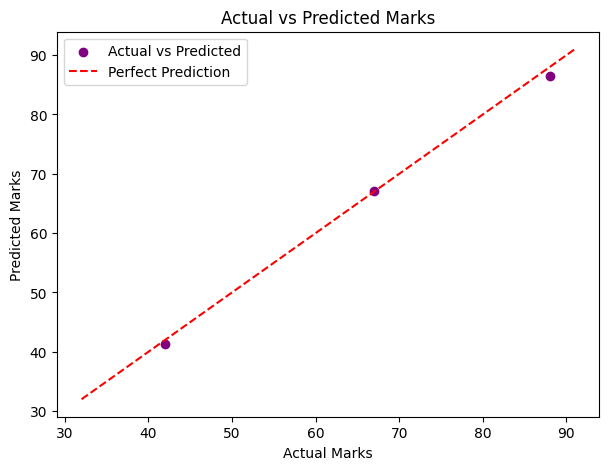

In [153]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Purple', label='Actual vs Predicted')

# Perfect Prediction Line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')
plt.legend()
plt.show()

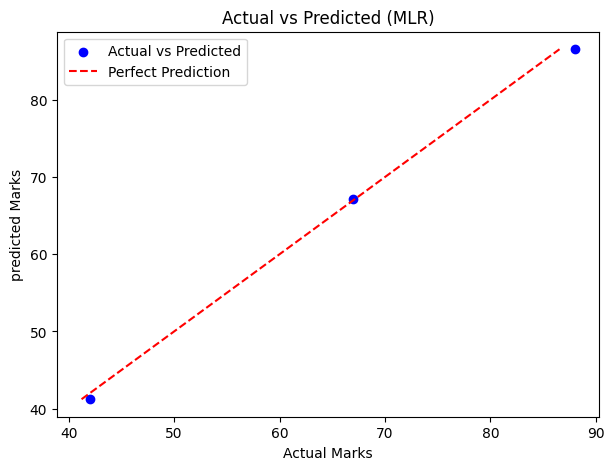

In [155]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs Predicted')
plt.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Marks')
plt.ylabel('predicted Marks')
plt.title('Actual vs Predicted (MLR)')
plt.legend()
plt.show()

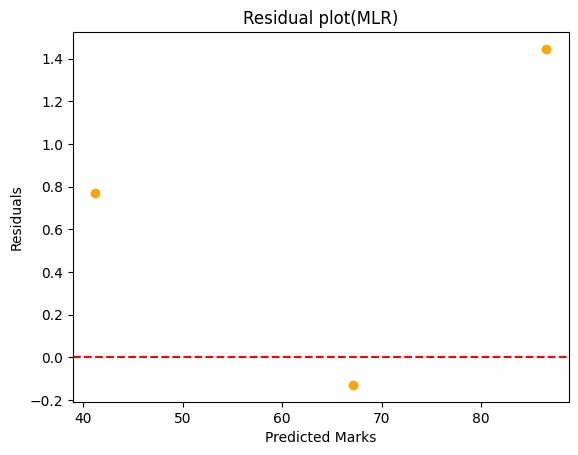

In [156]:
residuals = y_test - y_pred #calculate residual

plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='red',
            linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual plot(MLR)')
plt.show()